In [ ]:
!pip install torch torchvision numpy matplotlib imageio tqdm scikit-image trimesh pillow

In [ ]:
import urllib.request, zipfile, json
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio
from pathlib import Path
from tqdm import tqdm
from PIL import Image as PILImage

# 下載資料集（約 240MB，已存在則跳過）
zip_path = Path("nerf_synthetic.zip")
if not zip_path.exists():
    urllib.request.urlretrieve(
        "https://huggingface.co/donydchen/matchnerf/resolve/main/nerf_synthetic.zip",
        zip_path
    )
if not Path("nerf_synthetic/lego").exists():
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(".")

SCENE_DIR = Path("nerf_synthetic/lego")

In [16]:
class NeRF(nn.Module):
    def __init__(self, pos_dim, dir_dim, hidden=256):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Linear(pos_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),  nn.ReLU(),
            nn.Linear(hidden, hidden),  nn.ReLU(),
            nn.Linear(hidden, hidden),  nn.ReLU(),
        )
        self.block2 = nn.Sequential(
            nn.Linear(hidden + pos_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),           nn.ReLU(),
            nn.Linear(hidden, hidden),           nn.ReLU(),
            nn.Linear(hidden, hidden + 1),
        )
        self.color_head = nn.Sequential(
            nn.Linear(hidden + dir_dim, hidden // 2), nn.ReLU(),
            nn.Linear(hidden // 2, 3),                nn.Sigmoid(),
        )

    def forward(self, pos_enc, dir_enc):
        h = self.block1(pos_enc)
        h = self.block2(torch.cat([h, pos_enc], dim=-1))
        sigma = torch.relu(h[..., 0])
        rgb = self.color_head(torch.cat([h[..., 1:], dir_enc], dim=-1))
        return rgb, sigma


def positional_encoding(x, num_freqs):
    freqs = 2.0 ** torch.linspace(0, num_freqs - 1, num_freqs, device=x.device)
    return torch.cat([x] + [fn(f * x) for f in freqs for fn in (torch.sin, torch.cos)], dim=-1)


def get_rays(H, W, focal, c2w):
    i, j = torch.meshgrid(
        torch.arange(W, dtype=torch.float32, device=c2w.device),
        torch.arange(H, dtype=torch.float32, device=c2w.device),
        indexing='xy'
    )
    dirs = torch.stack([(i - W*0.5)/focal, -(j - H*0.5)/focal, -torch.ones_like(i)], dim=-1)
    rays_d = (dirs[..., None, :] * c2w[:3, :3]).sum(-1)
    rays_o = c2w[:3, 3].expand(rays_d.shape)
    return rays_o, rays_d


def sample_points(rays_o, rays_d, near, far, n_samples, perturb=False):
    t_vals = torch.linspace(0, 1, n_samples, device=rays_o.device)
    z_vals = (near * (1 - t_vals) + far * t_vals).expand(rays_o.shape[0], n_samples)
    if perturb:
        mids  = 0.5 * (z_vals[..., 1:] + z_vals[..., :-1])
        upper = torch.cat([mids, z_vals[..., -1:]], dim=-1)
        lower = torch.cat([z_vals[..., :1], mids],  dim=-1)
        z_vals = lower + (upper - lower) * torch.rand_like(z_vals)
    return rays_o[..., None, :] + rays_d[..., None, :] * z_vals[..., :, None], z_vals


def volume_render(rgb, sigma, z_vals):
    deltas = torch.cat([z_vals[..., 1:] - z_vals[..., :-1], torch.full_like(z_vals[..., :1], 1e10)], dim=-1)
    alpha   = 1.0 - torch.exp(-sigma * deltas)
    T       = torch.cumprod(torch.cat([torch.ones_like(alpha[..., :1]), 1 - alpha + 1e-10], dim=-1), dim=-1)[..., :-1]
    weights = T * alpha
    return (weights[..., None] * rgb).sum(dim=-2), weights


def render_pose(pose, H, W, focal):
    model.eval()
    pose = pose.to(device)
    rays_o, rays_d = get_rays(H, W, focal, pose)
    rays_o, rays_d = rays_o.reshape(-1, 3), rays_d.reshape(-1, 3)
    chunks = []
    with torch.no_grad():
        for k in range(0, rays_o.shape[0], BATCH_RAY):
            ro, rd = rays_o[k:k+BATCH_RAY], rays_d[k:k+BATCH_RAY]
            pts, z_vals = sample_points(ro, rd, NEAR, FAR, N_SAMPLES)
            pos_enc = positional_encoding(pts.reshape(-1, 3),                   num_freqs=POS_FREQS)
            dir_enc = positional_encoding(rd[:, None].expand_as(pts).reshape(-1, 3), num_freqs=DIR_FREQS)
            rgb_raw, sigma_raw = model(pos_enc, dir_enc)
            rgb_map, _ = volume_render(rgb_raw.reshape(-1, N_SAMPLES, 3), sigma_raw.reshape(-1, N_SAMPLES), z_vals)
            chunks.append(rgb_map.cpu())
    return torch.cat(chunks).reshape(H, W, 3).numpy().clip(0, 1)

In [17]:
SCALE     = 0.5
device    = "cuda" if torch.cuda.is_available() else "cpu"
POS_FREQS, DIR_FREQS = 10, 4
pos_dim   = 3 + 3 * 2 * POS_FREQS
dir_dim   = 3 + 3 * 2 * DIR_FREQS
N_ITERS   = 30000
N_SAMPLES = 64
NEAR, FAR = 2.0, 6.0
BATCH_RAY = 1024

def load_split(split):
    meta  = json.loads((SCENE_DIR / f"transforms_{split}.json").read_text())
    focal = 0.5 * 800 / np.tan(0.5 * meta["camera_angle_x"]) * SCALE
    imgs, poses = [], []
    for frame in meta["frames"]:
        img = imageio.imread(SCENE_DIR / (frame["file_path"].lstrip("./") + ".png")).astype(np.float32) / 255.0
        img = np.array(PILImage.fromarray((img*255).astype(np.uint8)).resize(
            (int(img.shape[1]*SCALE), int(img.shape[0]*SCALE)))) / 255.0
        if img.shape[-1] == 4:
            img = img[..., :3] * img[..., 3:] + (1 - img[..., 3:])
        imgs.append(img)
        poses.append(np.array(frame["transform_matrix"], dtype=np.float32))
    H, W = imgs[0].shape[:2]
    return torch.tensor(np.stack(imgs), dtype=torch.float32), torch.tensor(np.stack(poses), dtype=torch.float32), H, W, focal

images_t, poses_t, H, W, focal = load_split("train")
test_imgs, test_poses, _, _, _  = load_split("test")
testimg, testpose = test_imgs[0], test_poses[0]

model     = NeRF(pos_dim=pos_dim, dir_dim=dir_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
losses    = []

for i in tqdm(range(N_ITERS)):
    idx  = np.random.randint(len(images_t))
    img  = images_t[idx].to(device)
    pose = poses_t[idx].to(device)

    rays_o, rays_d = get_rays(H, W, focal, pose)
    rays_o, rays_d = rays_o.reshape(-1, 3), rays_d.reshape(-1, 3)
    target = img.reshape(-1, 3)

    sel = np.random.choice(rays_o.shape[0], BATCH_RAY, replace=False)
    rays_o, rays_d, target = rays_o[sel], rays_d[sel], target[sel]

    pts, z_vals = sample_points(rays_o, rays_d, NEAR, FAR, N_SAMPLES, perturb=True)
    pos_enc = positional_encoding(pts.reshape(-1, 3),                        num_freqs=POS_FREQS)
    dir_enc = positional_encoding(rays_d[:, None].expand_as(pts).reshape(-1, 3), num_freqs=DIR_FREQS)

    rgb_raw, sigma_raw = model(pos_enc, dir_enc)
    rgb_map, _ = volume_render(rgb_raw.reshape(BATCH_RAY, N_SAMPLES, 3), sigma_raw.reshape(BATCH_RAY, N_SAMPLES), z_vals)

    loss = ((rgb_map - target) ** 2).mean()
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    losses.append(loss.item())

torch.save(model.state_dict(), "nerf_lego.pt")

100%|██████████| 30000/30000 [20:43<00:00, 24.13it/s]


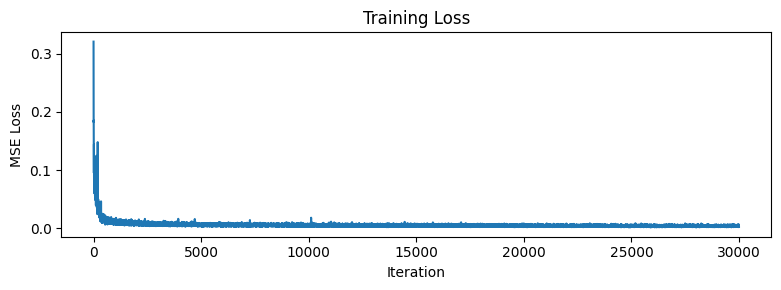

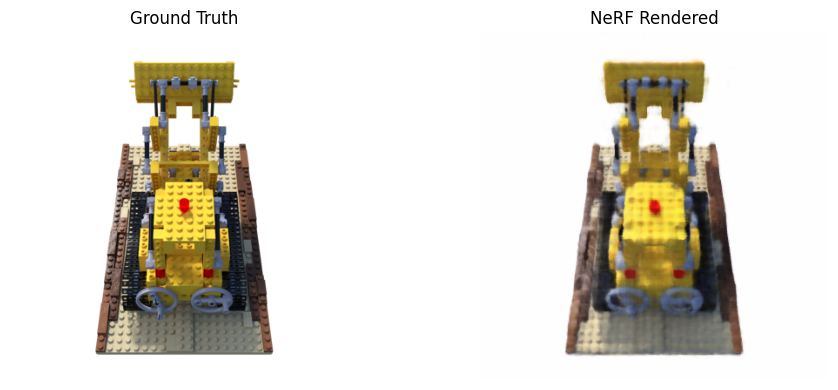

In [19]:
plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.xlabel("Iteration"); plt.ylabel("MSE Loss"); plt.title("Training Loss")
plt.tight_layout(); plt.show()

rendered = render_pose(testpose, H, W, focal)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(testimg.numpy()); axes[0].set_title("Ground Truth")
axes[1].imshow(rendered);        axes[1].set_title("NeRF Rendered")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

In [20]:
def make_orbit_pose(theta, phi=30.0, radius=4.0):
    theta, phi = np.radians(theta), np.radians(phi)
    cam_pos = np.array([radius*np.cos(phi)*np.sin(theta), radius*np.sin(phi), radius*np.cos(phi)*np.cos(theta)])
    z = cam_pos / np.linalg.norm(cam_pos)
    x = np.cross([0, 1, 0], z); x /= np.linalg.norm(x)
    y = np.cross(z, x)
    c2w = np.eye(4, dtype=np.float32)
    c2w[:3, 0], c2w[:3, 1], c2w[:3, 2], c2w[:3, 3] = x, y, z, cam_pos
    return torch.tensor(c2w)

frames = []
for theta in tqdm(np.linspace(0, 360, 40, endpoint=False)):
    frame = render_pose(make_orbit_pose(theta), H, W, focal)
    frames.append((frame * 255).astype(np.uint8))

imageio.mimsave("nerf_lego_orbit.mp4", frames, fps=24, quality=9)

from IPython.display import Video
Video("nerf_lego_orbit.mp4", embed=True)

100%|██████████| 40/40 [01:26<00:00,  2.16s/it]


In [32]:
from skimage.measure import marching_cubes
import trimesh

GRID_RES  = 128          # 解析度，越高越細緻但越慢（建議 128~256）
THRESHOLD = 10.0         # density 閾值，調高 → 物體更緊實，調低 → 更多細節
BOUND     = 1.5          # 場景邊界（lego 場景約在 ±1.5 範圍內）

# 在 3D grid 上查詢 density
coords = torch.linspace(-BOUND, BOUND, GRID_RES)
grid_x, grid_y, grid_z = torch.meshgrid(coords, coords, coords, indexing='ij')
pts_grid = torch.stack([grid_x, grid_y, grid_z], dim=-1).reshape(-1, 3).to(device)

sigma_grid = []
model.eval()
with torch.no_grad():
    for k in range(0, pts_grid.shape[0], 8192):
        chunk = pts_grid[k:k+8192]
        pos_enc = positional_encoding(chunk, num_freqs=POS_FREQS)
        dir_dummy = torch.zeros(chunk.shape[0], dir_dim, device=device)
        h = model.block1(pos_enc)
        h = model.block2(torch.cat([h, pos_enc], dim=-1))
        sigma_grid.append(torch.relu(h[..., 0]).cpu())

sigma_vol = torch.cat(sigma_grid).reshape(GRID_RES, GRID_RES, GRID_RES).numpy()

# Marching Cubes → vertices & faces
vertices, faces, _, _ = marching_cubes(sigma_vol, level=THRESHOLD)

# 座標從 grid index 還原到世界座標
vertices = vertices / (GRID_RES - 1) * (2 * BOUND) - BOUND

mesh = trimesh.Trimesh(vertices=vertices, faces=faces)
mesh.export("nerf_lego.obj")
print(f"頂點數：{len(vertices)}，面數：{len(faces)}，已儲存為 nerf_lego.obj")

頂點數：297030，面數：587180，已儲存為 nerf_lego.obj
